In [1]:
# Install libraries (Jawaban Pertanyaan #1 & #4)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Cek 10 data pertama
df.head(10)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


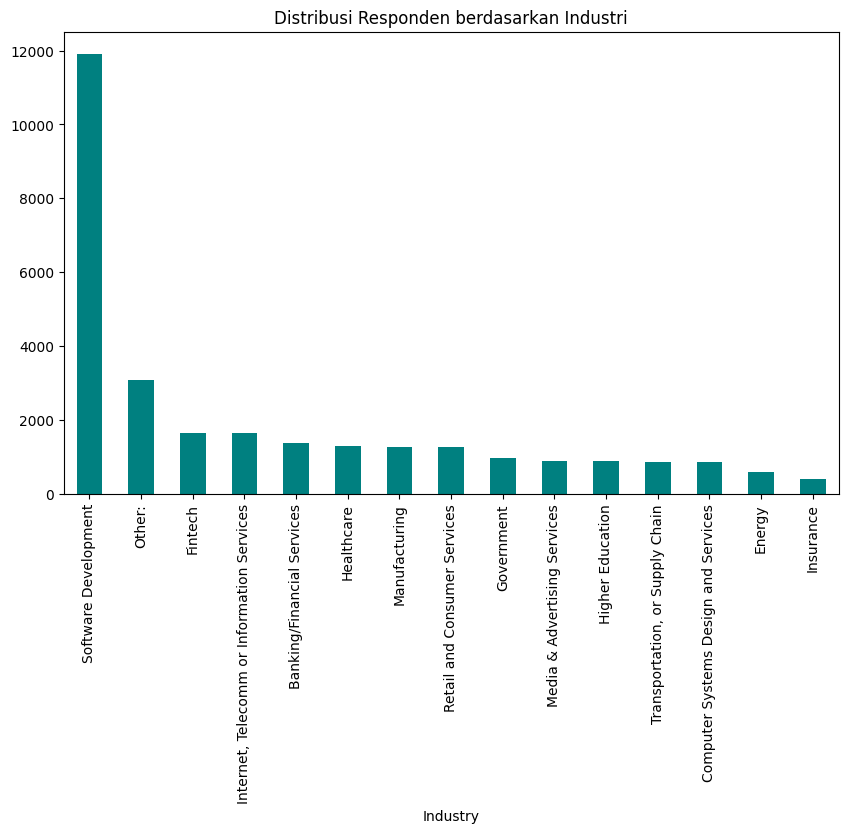

Five-Number Summary untuk Kolom Age:
min    18.0
25%    18.0
50%    25.0
75%    35.0
max    65.0
Name: Age_Numeric, dtype: float64


In [2]:
# Langkah 2: Distribusi Industri & Deskripsi Umur (Pertanyaan #7)
# Visualisasi Distribusi Industri
plt.figure(figsize=(10,6))
df['Industry'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribusi Responden berdasarkan Industri')
plt.show()

# Transformasi Age ke Numerik untuk Five-Number Summary
# Mengambil angka pertama (misal: '25-34' jadi 25)
df['Age_Numeric'] = df['Age'].str.extract('(\d+)').astype(float)

# Five-Number Summary untuk Age (Jawaban Pertanyaan #7)
# (Min, 25%, Median, 75%, Max)
print("Five-Number Summary untuk Kolom Age:")
print(df['Age_Numeric'].describe()[['min', '25%', '50%', '75%', 'max']])

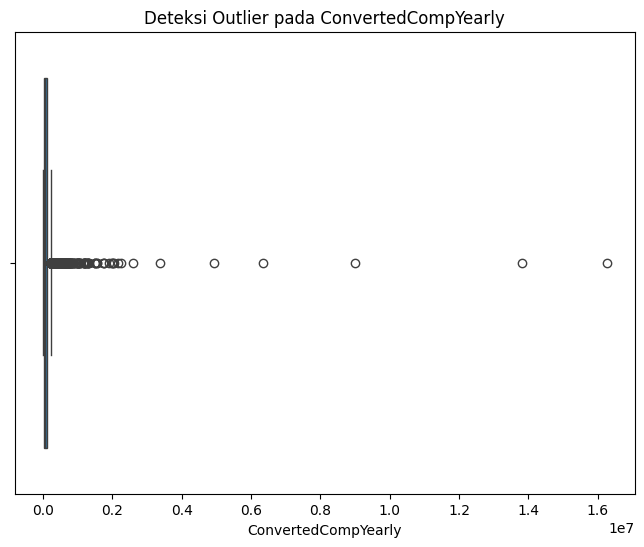

In [4]:
# Langkah 3: Deteksi Outlier Kompensasi (Pertanyaan #3)
# Plot Box Plot (Jawaban Pertanyaan #3)
plt.figure(figsize=(8,6))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title('Deteksi Outlier pada ConvertedCompYearly')
plt.show()

In [5]:
# Langkah 4: Menghapus Outlier (Pertanyaan #5 & #6)
# Menghitung IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Membuat DataFrame Baru tanpa Outlier (Jawaban Pertanyaan #5 & #6)
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print(f"Jumlah baris sebelum dihapus: {len(df)}")
print(f"Jumlah baris setelah outlier dihapus: {len(df_no_outliers)}")

Jumlah baris sebelum dihapus: 65437
Jumlah baris setelah outlier dihapus: 22457


Matriks Korelasi:
                     Age_Numeric  ConvertedCompYearly  YearsCodePro
Age_Numeric             1.000000             0.363585      0.826475
ConvertedCompYearly     0.363585             1.000000      0.387209
YearsCodePro            0.826475             0.387209      1.000000


/tmp/ipykernel_712/3667836863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')


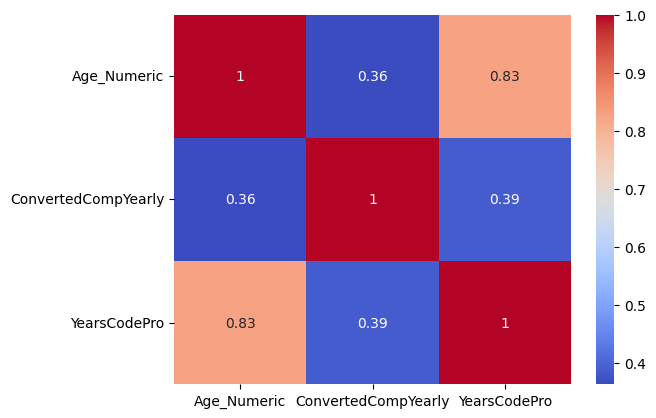

In [8]:
# Langkah 5: Analisis Korelasi (Pertanyaan #2)
 # Menangani YearsCodePro agar numerik
df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')

# Korelasi antara Age dan kolom numerik lainnya (Jawaban Pertanyaan #2)
correlation_matrix = df_no_outliers[['Age_Numeric', 'ConvertedCompYearly', 'YearsCodePro']].corr()

print("Matriks Korelasi:")
print(correlation_matrix)

# Visualisasi Heatmap Korelasi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()                             